In [74]:
import os
import sys

import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath(os.path.join("modelling", '../..')))

from utility import plot

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from xgboost import XGBClassifier # Added XGBClassifier
from sklearn.ensemble import RandomForestClassifier # Added RandomForestClassifier

from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [75]:
SEED = 42
PLOT_DPI = 100

TRAIN_DATA_FILE = "../../datasets/Skoltech_Anomaly_Benchmark/preprocessed_skab_dataset_set2_train.csv"
TEST_DATA_FILE = "../../datasets/Skoltech_Anomaly_Benchmark/preprocessed_skab_dataset_set2_test.csv"

USE_LDA = False

In [76]:
dataframe_train = pd.read_csv(TRAIN_DATA_FILE)
# dataframe_train.set_index(pd.to_datetime(dataframe_train.datetime), drop=True, inplace=True)
# dataframe_train.drop(columns=["datetime"], inplace=True)
dataframe_train.head()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,AccelerometerRMS_Fluctuation,Temperature_Fluctuation,Thermocouple_Fluctuation,Volume Flow RateRMS_Fluctuation,Hydraulic_Power_Fluctuation,Electrical_Power_Fluctuation,description,anomaly
0,0.219595,0.267058,2.97205,1.074847,88.9166,28.9319,227.339,127.0000,76.492320,0.008463,...,0.154822,0.006604,0.000495,0.059292,0.002836,0.052960,13.772706,101.000067,No Anomaly,0.0
1,0.028225,0.042124,1.43210,1.401284,68.6462,24.7640,245.677,32.9805,171.550171,0.042488,...,0.229541,0.005869,0.000024,0.086108,0.003364,0.161704,5.272073,27.131990,No Anomaly,0.0
2,0.214053,0.259569,2.22898,1.730701,88.2787,29.6790,227.822,127.0000,102.209082,0.013628,...,0.204520,0.014483,0.000405,0.238396,0.004220,0.210480,47.116885,38.577988,No Anomaly,0.0
3,0.255422,0.294430,2.99871,1.074847,86.2073,28.8126,232.379,126.0000,77.492989,0.008531,...,0.145544,0.006640,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,No Anomaly,0.0
4,0.081667,0.129274,1.56118,0.733489,87.2407,22.1358,234.136,77.0000,149.973738,0.009526,...,0.280788,0.004654,0.000065,0.076840,0.004868,0.389792,7.142787,32.665876,No Anomaly,0.0


In [77]:
dataframe_test = pd.read_csv(TEST_DATA_FILE)
# dataframe_test.set_index(pd.to_datetime(dataframe_test.datetime), drop=True, inplace=True)
# dataframe_test.drop(columns=["datetime"], inplace=True)
dataframe_test.head()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,AccelerometerRMS_Fluctuation,Temperature_Fluctuation,Thermocouple_Fluctuation,Volume Flow RateRMS_Fluctuation,Hydraulic_Power_Fluctuation,Electrical_Power_Fluctuation,description,anomaly
0,0.210323,0.262893,2.65864,1.074847,88.6217,29.3147,230.091,126.677,86.544624,0.008485,...,0.170436,0.007359,0.000450,0.115096,0.005824,0.285160,8.584219,126.989244,No Anomaly,0.0
1,0.028297,0.042536,0.81412,0.745430,68.0318,24.2354,232.174,32.000,285.184002,0.023295,...,0.423439,0.005650,0.000042,0.111232,0.004348,0.038412,16.180027,34.680405,No Anomaly,0.0
2,0.028185,0.041387,0.81061,1.073357,68.8750,24.7075,208.422,32.000,257.117479,0.033542,...,0.479609,0.009025,0.000026,0.029276,0.006124,0.199256,12.170266,28.633766,No Anomaly,0.0
3,0.027955,0.042217,1.12593,1.073357,68.9973,24.7679,235.556,27.000,209.210164,0.039754,...,0.306061,0.004844,0.000024,0.018756,0.002284,0.310260,8.450375,7.272027,Inlet Valve Malfunction,12.0
4,0.211749,0.272061,2.65451,1.402774,90.2739,27.8473,225.678,123.668,85.016820,0.011343,...,0.177284,0.009096,0.000340,0.075920,0.004140,0.320000,21.923342,83.523038,No Anomaly,0.0


In [78]:
scaler = StandardScaler()

values = scaler.fit_transform(dataframe_train.drop(columns=["anomaly", "description"]).values)

if USE_LDA:
    lda = LinearDiscriminantAnalysis()
    values = lda.fit_transform(values, dataframe_train.anomaly.to_numpy().ravel())
    dataframe_train_scaled = pd.DataFrame(values, columns=[f"Linear_Discriminant_{idx}" for idx in range(1, values.shape[1]+1)])
else:
    dataframe_train_scaled = pd.DataFrame(values, columns=dataframe_train.drop(columns=["anomaly", "description"]).columns)

dataframe_train_scaled = dataframe_train_scaled.assign(anomaly=dataframe_train.anomaly.values, description=dataframe_train.description.values)
dataframe_train_scaled

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,AccelerometerRMS_Fluctuation,Temperature_Fluctuation,Thermocouple_Fluctuation,Volume Flow RateRMS_Fluctuation,Hydraulic_Power_Fluctuation,Electrical_Power_Fluctuation,anomaly,description
0,0.716365,0.726329,1.652512,-0.090802,1.032226,0.941960,-0.211177,1.140473,-1.070802,-0.213946,...,-1.017678,-0.379142,-0.008780,-0.438492,-0.058108,-0.222847,-0.438263,1.758921,0.0,No Anomaly
1,-0.792652,-0.828083,-0.274864,1.176801,-1.126862,-0.688316,1.478174,-0.923284,-0.100686,0.195903,...,-0.523057,-0.577511,-0.155598,-0.022696,-0.042907,-0.162611,-0.927125,-0.751316,0.0,No Anomaly
2,0.672664,0.674576,0.722498,2.455973,0.964280,1.234189,-0.166682,1.140473,-0.808349,-0.151740,...,-0.688691,1.748097,-0.036868,2.338607,-0.018265,-0.135593,1.479325,-0.362350,0.0,No Anomaly
3,0.998872,0.915484,1.685880,-0.090802,0.743647,0.895296,0.253123,1.118523,-1.060590,-0.213136,...,-1.079101,-0.369533,-0.163221,-1.357845,-0.139751,-0.252182,-1.230317,-1.673335,0.0,No Anomaly
4,-0.371240,-0.225833,-0.113309,-1.416344,0.853718,-1.716338,0.414983,0.042958,-0.320885,-0.201148,...,-0.183807,-0.905769,-0.142921,-0.166401,0.000390,-0.036268,-0.819543,-0.563260,0.0,No Anomaly
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34436,-0.793062,-0.830924,-1.002349,-1.369975,-0.894916,-0.507370,0.369658,-0.923029,0.951005,-0.043732,...,0.732021,-0.725851,-0.153520,-0.831588,-0.015040,-0.054610,-0.859702,-0.490525,0.0,No Anomaly
34437,-0.377952,-0.236648,-0.046487,-0.142957,0.839659,-1.713444,0.057822,0.042532,-0.396003,-0.149806,...,-0.217775,-0.371197,-0.125820,0.006764,-0.075150,-0.016267,0.113086,0.827075,0.0,No Anomaly
34438,-0.797043,-0.834040,-0.305515,1.176801,-1.076928,-0.664339,0.787804,-0.944806,-0.124560,0.211585,...,-0.437089,-0.563500,-0.154736,0.478008,-0.021028,-0.054275,-0.631361,-0.224393,0.0,No Anomaly
34439,0.635879,0.695162,1.383122,-0.090802,0.985754,1.190419,0.579975,1.155421,-0.978060,-0.214489,...,-0.983103,-0.266101,-0.075947,-0.714304,-0.068702,-0.105194,1.824352,-1.056801,0.0,No Anomaly


In [79]:
values = scaler.transform(dataframe_test.drop(columns=["anomaly", "description"]).values)

if USE_LDA:
    values = lda.transform(values)
    dataframe_test_scaled = pd.DataFrame(values, columns=[f"Linear_Discriminant_{idx}" for idx in range(1, values.shape[1]+1)])
else:
    dataframe_test_scaled = pd.DataFrame(values, columns=dataframe_test.drop(columns=["anomaly", "description"]).columns)

dataframe_test_scaled = dataframe_test_scaled.assign(anomaly=dataframe_test.anomaly.values, description=dataframe_test.description.values)
dataframe_test_scaled

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,AccelerometerRMS_Fluctuation,Temperature_Fluctuation,Thermocouple_Fluctuation,Volume Flow RateRMS_Fluctuation,Hydraulic_Power_Fluctuation,Electrical_Power_Fluctuation,anomaly,description
0,0.643252,0.697546,1.260254,-0.090802,1.000815,1.091693,0.042345,1.133383,-0.968213,-0.213686,...,-0.914317,-0.175354,-0.022947,0.426778,0.027911,-0.094226,-0.736647,2.642104,0.0,No Anomaly
1,-0.792086,-0.825237,-1.048317,-1.369975,-1.192304,-0.895078,0.234237,-0.944806,1.059007,-0.035294,...,0.760515,-0.636730,-0.150219,0.366864,-0.014580,-0.230905,-0.299821,-0.494801,0.0,No Anomaly
2,-0.792968,-0.833182,-1.052710,-0.096587,-1.102492,-0.710416,-1.953867,-0.944806,0.772573,0.088146,...,1.132348,0.274598,-0.155050,-0.903905,0.036548,-0.141810,-0.530418,-0.700282,0.0,No Anomaly
3,-0.794783,-0.827444,-0.658061,-0.096587,-1.089465,-0.686791,0.545797,-1.054557,0.283654,0.162967,...,-0.016508,-0.854283,-0.155747,-1.067023,-0.073999,-0.080323,-0.744345,-1.426212,12.0,Inlet Valve Malfunction
4,0.654496,0.760902,1.255085,1.182585,1.176798,0.517718,-0.364193,1.067334,-0.983805,-0.179258,...,-0.868986,0.293556,-0.057072,-0.180666,-0.020568,-0.074927,0.030471,1.165005,0.0,No Anomaly
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7376,-0.801370,-0.844196,-0.632967,-0.096587,-1.023618,-0.604141,0.063810,-0.966756,0.199704,0.101179,...,0.011503,-0.667036,-0.157852,-0.559435,-0.032659,-0.078823,-0.185380,-0.185526,12.0,Inlet Valve Malfunction
7377,0.634680,0.686863,1.102254,-0.090802,1.039298,1.036775,-0.619927,1.118523,-0.953155,-0.213136,...,-0.814887,-0.038511,-0.065314,1.168127,-0.045326,-0.038125,1.012946,-0.522988,0.0,No Anomaly
7378,-0.798398,-0.844808,-1.292549,-0.096587,-1.162576,-0.792558,-0.057424,-0.944110,1.924345,0.087746,...,1.710510,0.768499,-0.153768,0.085222,-0.016307,-0.043757,-0.815301,-0.594002,0.0,No Anomaly
7379,0.901544,0.866696,0.837306,1.182585,0.673645,1.158658,1.889227,1.148902,-0.751438,-0.183244,...,-0.894829,0.744480,0.229986,0.102216,0.029984,0.002600,1.040267,1.987354,0.0,No Anomaly


In [80]:
X_train_scaled = dataframe_train.drop(columns=["anomaly", "description"]).values
y_train = dataframe_train["anomaly"].values.ravel()

X_test_scaled = dataframe_test.drop(columns=["anomaly", "description"]).values
y_test = dataframe_test["anomaly"].values.ravel()

In [81]:
combined = zip(dataframe_train.anomaly.values, dataframe_train.description.values)
sorted_pairs = sorted(combined, key=lambda pair: pair[0])

anomaly_ids = dict()
for i in sorted_pairs:
    anomaly_ids[i[0]] = i[1]

anomaly_names = [val for key, val in anomaly_ids.items()]

In [82]:
def format_cf(cf):
    tp = cf[0, 0]
    fp = np.sum(cf[1:, 0])
    fn = np.sum(cf[0, 1:])
    tn = np.sum(cf[1:, 1:])
    return np.array([[tp, fn], [fp, tn]])

### Logistic Regression

In [99]:
model = LogisticRegression(
                                solver='newton-cholesky', 
                                multi_class='ovr', 
                                C=20) # 'lbfgs' is a good general-purpose solver
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8731


In [84]:
# plot.make_confusion_matrix(
#     confusion_matrix(y_test, y_pred),
#     categories=anomaly_names,
#     count=False,
#     cbar=False,
#     figsize=(20, 20)
# )

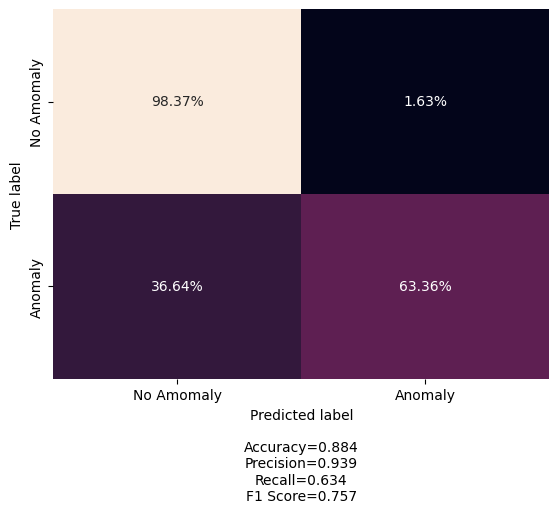

In [100]:
plot.make_confusion_matrix(
    format_cf(confusion_matrix(y_test, y_pred)),
    categories=["No Amomaly", "Anomaly",],
    count=False,
    cbar=False,
)

### SVM

In [ ]:
# 3. Instantiate and Train SVM
svm_model = SVC(kernel='linear', C=5.0, probability=True) # Example with RBF kernel
svm_model.fit(X_train_scaled, y_train)

# 4. Make Predictions and Evaluate
y_pred = svm_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

In [87]:
# plot.make_confusion_matrix(
#     confusion_matrix(y_test, y_pred),
#     categories=anomaly_names,
#     count=False,
#     cbar=False,
#     figsize=(20, 20)
# )

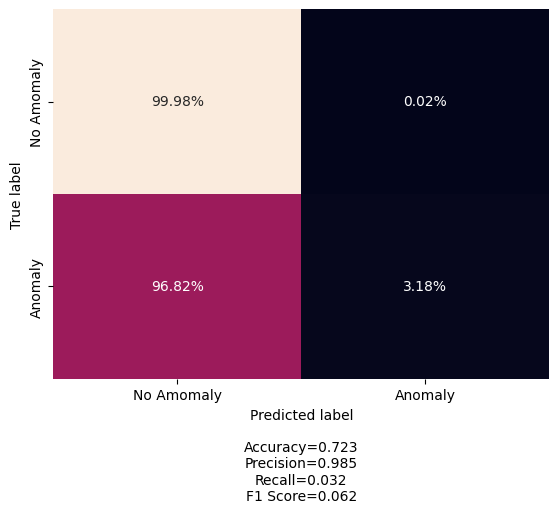

In [88]:
plot.make_confusion_matrix(
    format_cf(confusion_matrix(y_test, y_pred)),
    categories=["No Amomaly", "Anomaly",],
    count=False,
    cbar=False,
)

### Random Forest Classifier

In [89]:
model = RandomForestClassifier(n_estimators=100, random_state=SEED)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.9623


In [90]:
# plot.make_confusion_matrix(
#     confusion_matrix(y_test, y_pred),
#     categories=anomaly_names,
#     count=False,
#     cbar=False,
#     figsize=(20, 20)
# )

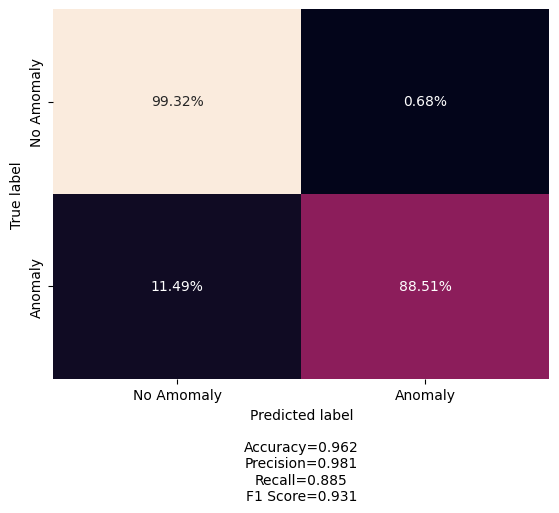

In [91]:
plot.make_confusion_matrix(
    format_cf(confusion_matrix(y_test, y_pred)),
    categories=["No Amomaly", "Anomaly",],
    count=False,
    cbar=False,
)

### XGBoost

In [92]:
model = XGBClassifier(objective='multi:softmax', num_class=len(anomaly_names), random_state=SEED)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.9713


In [93]:
# plot.make_confusion_matrix(
#     confusion_matrix(y_test, y_pred),
#     categories=anomaly_names,
#     count=False,
#     cbar=False,
#     figsize=(20, 20)
# )

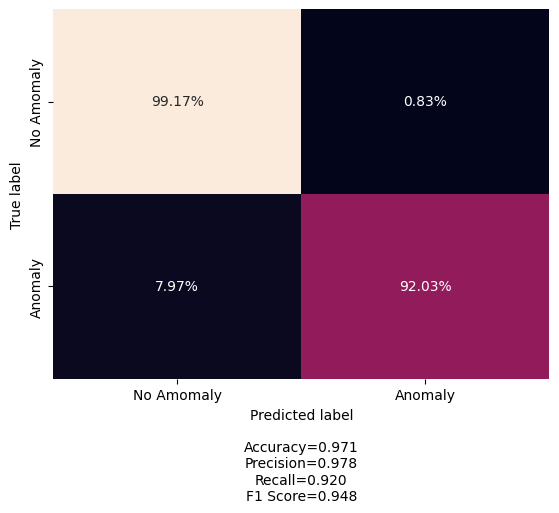

In [94]:
plot.make_confusion_matrix(
    format_cf(confusion_matrix(y_test, y_pred)),
    categories=["No Amomaly", "Anomaly",],
    count=False,
    cbar=False,
)

In [95]:
# # src/models.py (Updated with Supervised Multi-Class Classifiers)

# import pandas as pd
# import numpy as np
# from sklearn.covariance import MinCovDet
# from sklearn.svm import OneClassSVM
# from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors
# from scipy.stats import chi2
# from sklearn.neighbors import KernelDensity
# from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
# from sklearn.metrics import pairwise_distances
# from collections import Counter
# from xgboost import XGBClassifier # Added XGBClassifier
# from sklearn.ensemble import IsolationForest, RandomForestClassifier # Added RandomForestClassifier


# # --- Helper for common anomaly score to label conversion (ONLY for unsupervised methods) ---
# # Keep this helper as it might be useful if you later decide to re-evaluate unsupervised methods
# # for binary anomaly detection, but it IS NOT RELEVANT for the multi-class classification task.
# def _convert_scores_to_labels(scores: np.ndarray, contamination: float, score_lower_is_anomaly: bool = False) -> tuple[np.ndarray, float]:
#     """
#     Converts anomaly scores to binary labels (1 for anomaly, 0 for normal).
#     Args:
#         scores (np.ndarray): Array of anomaly scores.
#         contamination (float): Estimated proportion of anomalies.
#         score_lower_is_anomaly (bool): If True, lower scores mean more anomalous.
#                                        If False (default), higher scores mean more anomalous.
#     Returns:
#         tuple: (labels, threshold)
#     """
#     if len(scores) == 0:
#         return np.array([], dtype=int), 0.0

#     if score_lower_is_anomaly:
#         threshold = np.percentile(scores, 100 * contamination)
#         labels = (scores < threshold).astype(int)
#     else:
#         threshold = np.percentile(scores, 100 * (1 - contamination))
#         labels = (scores > threshold).astype(int)
#     return labels, threshold

# # --- Existing unsupervised anomaly detection functions (Z-score, Modified Z-score, etc.) ---
# # (For brevity, I'm not pasting the code for Z-score, Modified Z-score, Multivariate Gaussian,
# # Isolation Forest, One-Class SVM, LOF, IQR, Percentile, KDE, kNN_distance, K-Means AD, DBSCAN AD,
# # and Hierarchical AD here. They would remain in this file as previously provided.
# # However, for multi-class anomaly *type* classification, these functions are NOT suitable
# # and should not be called in main.py for this specific goal.)


# # ----------------------------------------------------------------------------------------------------------------------
# # NEW SUPERVISED MULTI-CLASS CLASSIFICATION IMPLEMENTATIONS BELOW
# # These models are designed to classify 14 distinct classes (1 Normal + 13 Anomaly Types).
# # ----------------------------------------------------------------------------------------------------------------------

# # --- 11. Random Forest Classifier for Anomaly Type Classification ---
# def train_evaluate_random_forest_classifier(
#     X_train: pd.DataFrame,
#     y_train: pd.Series, # Now actively used for training
#     X_test: pd.DataFrame,
#     y_test: pd.Series, # Not used for training, but here for consistent signature (will be passed to evaluation)
#     n_estimators: int = 100,
#     max_depth: int = None,
#     class_weight_strategy: str = 'balanced', # Default to 'balanced' for imbalance
#     random_state: int = 42
# ) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
#     """
#     Trains and evaluates a Random Forest Classifier for multi-class anomaly type classification.
#     This model can distinguish between different anomaly types.

#     Args:
#         X_train (pd.DataFrame): Training feature set.
#         y_train (pd.Series): Training target labels (0 for Normal, 1-13 for Anomaly Types).
#         X_test (pd.DataFrame): Test feature set.
#         y_test (pd.Series): Test target labels (not used for model's internal prediction process,
#                               but for evaluation in main script).
#         n_estimators (int): The number of trees in the forest.
#         max_depth (int, optional): The maximum depth of the tree.
#         class_weight_strategy (str, optional): Strategy for handling class imbalance.
#                                               'balanced' automatically adjusts weights inversely
#                                               proportional to class frequencies.
#                                               'balanced_subsample' is similar but subsamples for each tree.
#                                               None for no weighting.
#         random_state (int): Random seed for reproducibility.

#     Returns:
#         tuple: (train_predicted_labels, train_predicted_probabilities,
#                 test_predicted_labels, test_predicted_probabilities)
#                Where 'probabilities' are for each of the 14 classes.
#     """
#     print(f"  Training Random Forest Classifier (Multi-Class) with n_estimators={n_estimators}, max_depth={max_depth}, class_weight='{class_weight_strategy}'...")

#     model = RandomForestClassifier(
#         n_estimators=n_estimators,
#         max_depth=max_depth,
#         class_weight=class_weight_strategy, # Pass the string directly for sklearn's internal handling
#         random_state=random_state,
#         n_jobs=-1 # Use all available cores
#     )
    
#     # Train the model using the provided X_train and y_train
#     model.fit(X_train, y_train)

#     # Predict labels and probabilities for the training set
#     train_predicted_labels = model.predict(X_train)
#     train_predicted_probabilities = model.predict_proba(X_train) # Probabilities for each of the 14 classes

#     # Predict labels and probabilities for the test set
#     test_predicted_labels = model.predict(X_test)
#     test_predicted_probabilities = model.predict_proba(X_test)

#     print(f"  Random Forest Classifier trained.")
#     return train_predicted_labels, train_predicted_probabilities, test_predicted_labels, test_predicted_probabilities


# # --- 12. XGBoost Classifier for Anomaly Type Classification ---
# def train_evaluate_xgboost_classifier(
#     X_train: pd.DataFrame,
#     y_train: pd.Series,
#     X_test: pd.DataFrame,
#     y_test: pd.Series,
#     n_estimators: int = 100,
#     learning_rate: float = 0.1,
#     max_depth: int = 3,
#     use_sample_weights: bool = True, # Flag to enable custom sample weighting for imbalance
#     random_state: int = 42
# ) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
#     """
#     Trains and evaluates an XGBoost Classifier for multi-class anomaly type classification.
#     This model can distinguish between different anomaly types.

#     Args:
#         X_train (pd.DataFrame): Training feature set.
#         y_train (pd.Series): Training target labels (0 for Normal, 1-13 for Anomaly Types).
#         X_test (pd.DataFrame): Test feature set.
#         y_test (pd.Series): Test target labels (not used for model's internal prediction process,
#                               but for evaluation in main script).
#         n_estimators (int): Number of boosting rounds.
#         learning_rate (float): Step size shrinkage to prevent overfitting.
#         max_depth (int): Maximum depth of a tree.
#         use_sample_weights (bool): If True, computes and uses sample weights to address class imbalance.
#                                    Weights are inversely proportional to class frequencies.
#         random_state (int): Random seed for reproducibility.

#     Returns:
#         tuple: (train_predicted_labels, train_predicted_probabilities,
#                 test_predicted_labels, test_predicted_probabilities)
#                Where 'probabilities' are for each of the 14 classes.
#     """
#     print(f"  Training XGBoost Classifier (Multi-Class) with n_estimators={n_estimators}, learning_rate={learning_rate}, max_depth={max_depth}, use_sample_weights={use_sample_weights}...")

#     sample_weights = None
#     if use_sample_weights:
#         print(f"    Calculating and applying sample weights for class imbalance.")
#         # Calculate sample weights based on inverse of class frequencies
#         # This gives higher weight to samples from rarer classes.
#         classes = np.unique(y_train)
#         class_counts = Counter(y_train)
#         total_samples = len(y_train)
        
#         # Compute inverse of class frequency, then apply to each sample
#         # A common formula: weight_for_class_i = total_samples / (num_classes * count_of_class_i)
#         # Or simpler: total_samples / count_of_class_i
#         # Let's use total_samples / count_of_class_i for more pronounced weighting.
#         weights_dict = {cls: total_samples / count for cls, count in class_counts.items()}
#         sample_weights = np.array([weights_dict[label] for label in y_train])

#     # For multi-class classification, `objective` should be 'multi:softprob' to get probabilities
#     # `num_class` must be explicitly set to the number of unique classes.
#     model = XGBClassifier(
#         n_estimators=n_estimators,
#         learning_rate=learning_rate,
#         max_depth=max_depth,
#         objective='multi:softprob', # To get probabilities for each class
#         num_class=len(np.unique(y_train)), # Number of unique classes in the target variable
#         use_label_encoder=False, # Suppress warning for future versions (should be default False soon)
#         eval_metric='mlogloss', # Evaluation metric for multi-class classification
#         random_state=random_state,
#         n_jobs=-1 # Use all available cores
#     )
    
#     # Train the model using sample weights if enabled
#     model.fit(X_train, y_train, sample_weight=sample_weights)

#     # Predict probabilities for train and test sets
#     train_predicted_probabilities = model.predict_proba(X_train)
#     test_predicted_probabilities = model.predict_proba(X_test)

#     # Convert probabilities to class labels by selecting the class with the highest probability
#     train_predicted_labels = np.argmax(train_predicted_probabilities, axis=1)
#     test_predicted_labels = np.argmax(test_predicted_probabilities, axis=1)

#     print(f"  XGBoost Classifier trained.")
#     return train_predicted_labels, train_predicted_probabilities, test_predicted_labels, test_predicted_probabilities